# **LIBRARY**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pprint
import math
import warnings

from matplotlib.colors import ListedColormap, LinearSegmentedColormap, cnames
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

%matplotlib inline

# **DATA**

In [3]:
df = pd.read_csv(r"C:/JOSHUA BRYAN WIJAYA/SEMESTER 6/TPM/Projek Akhir/shoppers.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# **EKSPLORASI DATA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


| No | Peubah (Variable)            | Keterangan | Dtype | Jumlah Data Null |
|:---|:-----------------------------|:-----------|:------|:-----------------|
| 1  | Administrative               | Jumlah halaman kategori administratif yang dikunjungi | int64 | 0 |
| 2  | Administrative_Duration      | Total waktu yang dihabiskan pada halaman administratif | float64 | 0 |
| 3  | Informational                | Jumlah halaman kategori informasi yang dikunjungi | int64 | 0 |
| 4  | Informational_Duration       | Total waktu yang dihabiskan pada halaman informasi | float64 | 0 |
| 5  | ProductRelated               | Jumlah halaman produk yang dikunjungi | int64 | 0 |
| 6  | ProductRelated_Duration      | Total waktu yang dihabiskan pada halaman produk | float64 | 0 |
| 7  | BounceRates                  | Persentase pengunjung yang langsung keluar dari halaman tanpa interaksi | float64 | 0 |
| 8  | ExitRates                    | Persentase halaman yang menjadi halaman terakhir dalam sesi | float64 | 0 |
| 9  | PageValues                   | Nilai rata-rata halaman sebelum transaksi terjadi | float64 | 0 |
| 10 | SpecialDay                   | Kedekatan waktu kunjungan dengan hari spesial (misal Valentine, Mother's Day) | float64 | 0 |
| 11 | Month                        | Bulan kunjungan pengguna | object | 0 |
| 12 | OperatingSystems             | Sistem operasi yang digunakan pengunjung | int64 | 0 |
| 13 | Browser                      | Jenis browser yang digunakan pengunjung | int64 | 0 |
| 14 | Region                       | Wilayah asal pengunjung | int64 | 0 |
| 15 | TrafficType                  | Jenis sumber traffic pengunjung | int64 | 0 |
| 16 | VisitorType                  | Tipe pengunjung (Returning / New Visitor) | object | 0 |
| 17 | Weekend                      | Apakah kunjungan terjadi pada akhir pekan (True/False) | bool | 0 |
| 18 | Revenue                      | Target: apakah terjadi transaksi pembelian (True/False) | bool | 0 |

Tidak terdapat data null pada data. Kemudian, dataset terdiri dari peubah berikut:
- Terdapat 10 peubah Numerik : Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay
- Terdapat 8 peubah kategorik : Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend, Revenue

# **EKSPLORASI DATA**

## **Perbaikan Peubah**

In [7]:
categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

df[categorical_cols] = df[categorical_cols].astype("category")

## **Histogram Peubah Numerik**

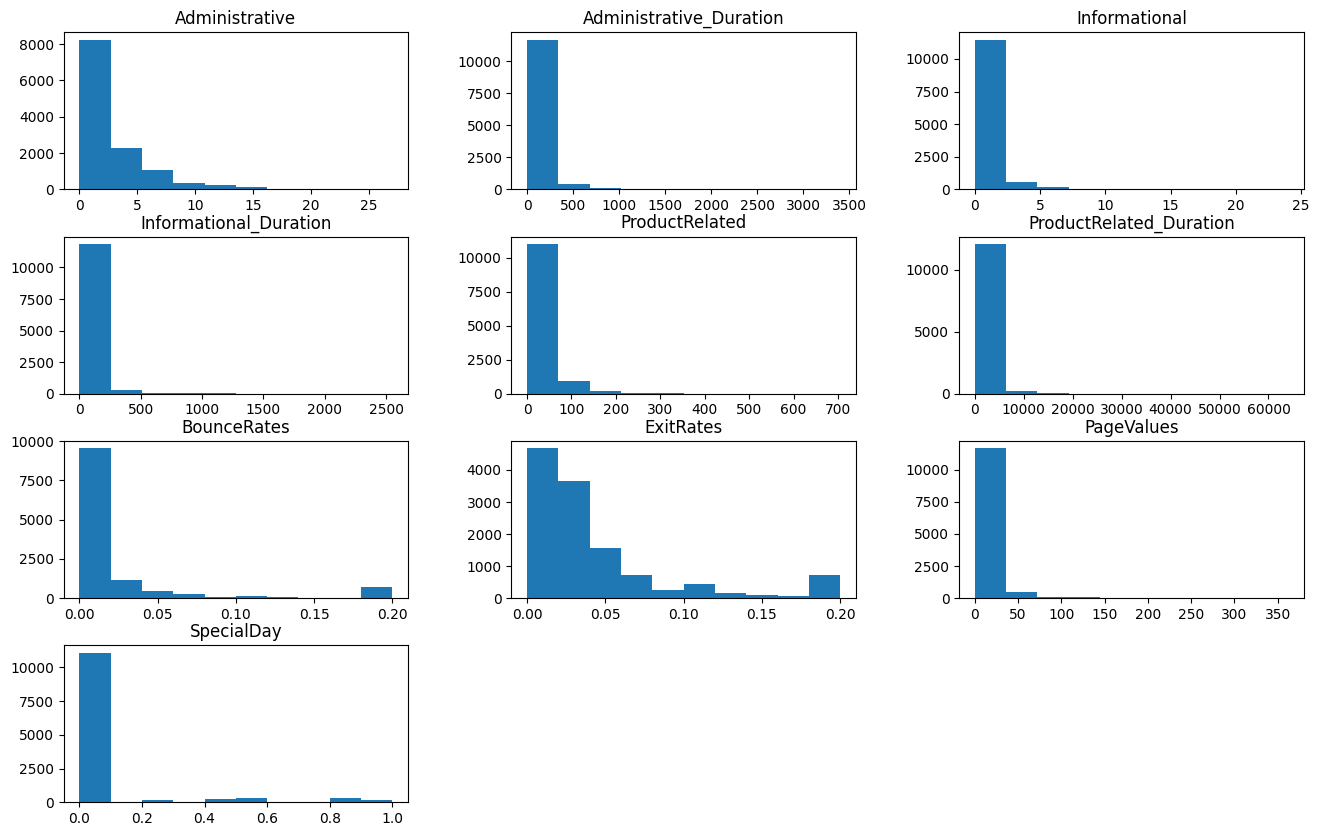

In [11]:
axes = df.hist(bins=10, figsize=(16, 10))

for ax in axes.flatten():
    ax.grid(False)

plt.show()

## **Hubungan Semua Peubah Numerik : Matriks Korelasi**

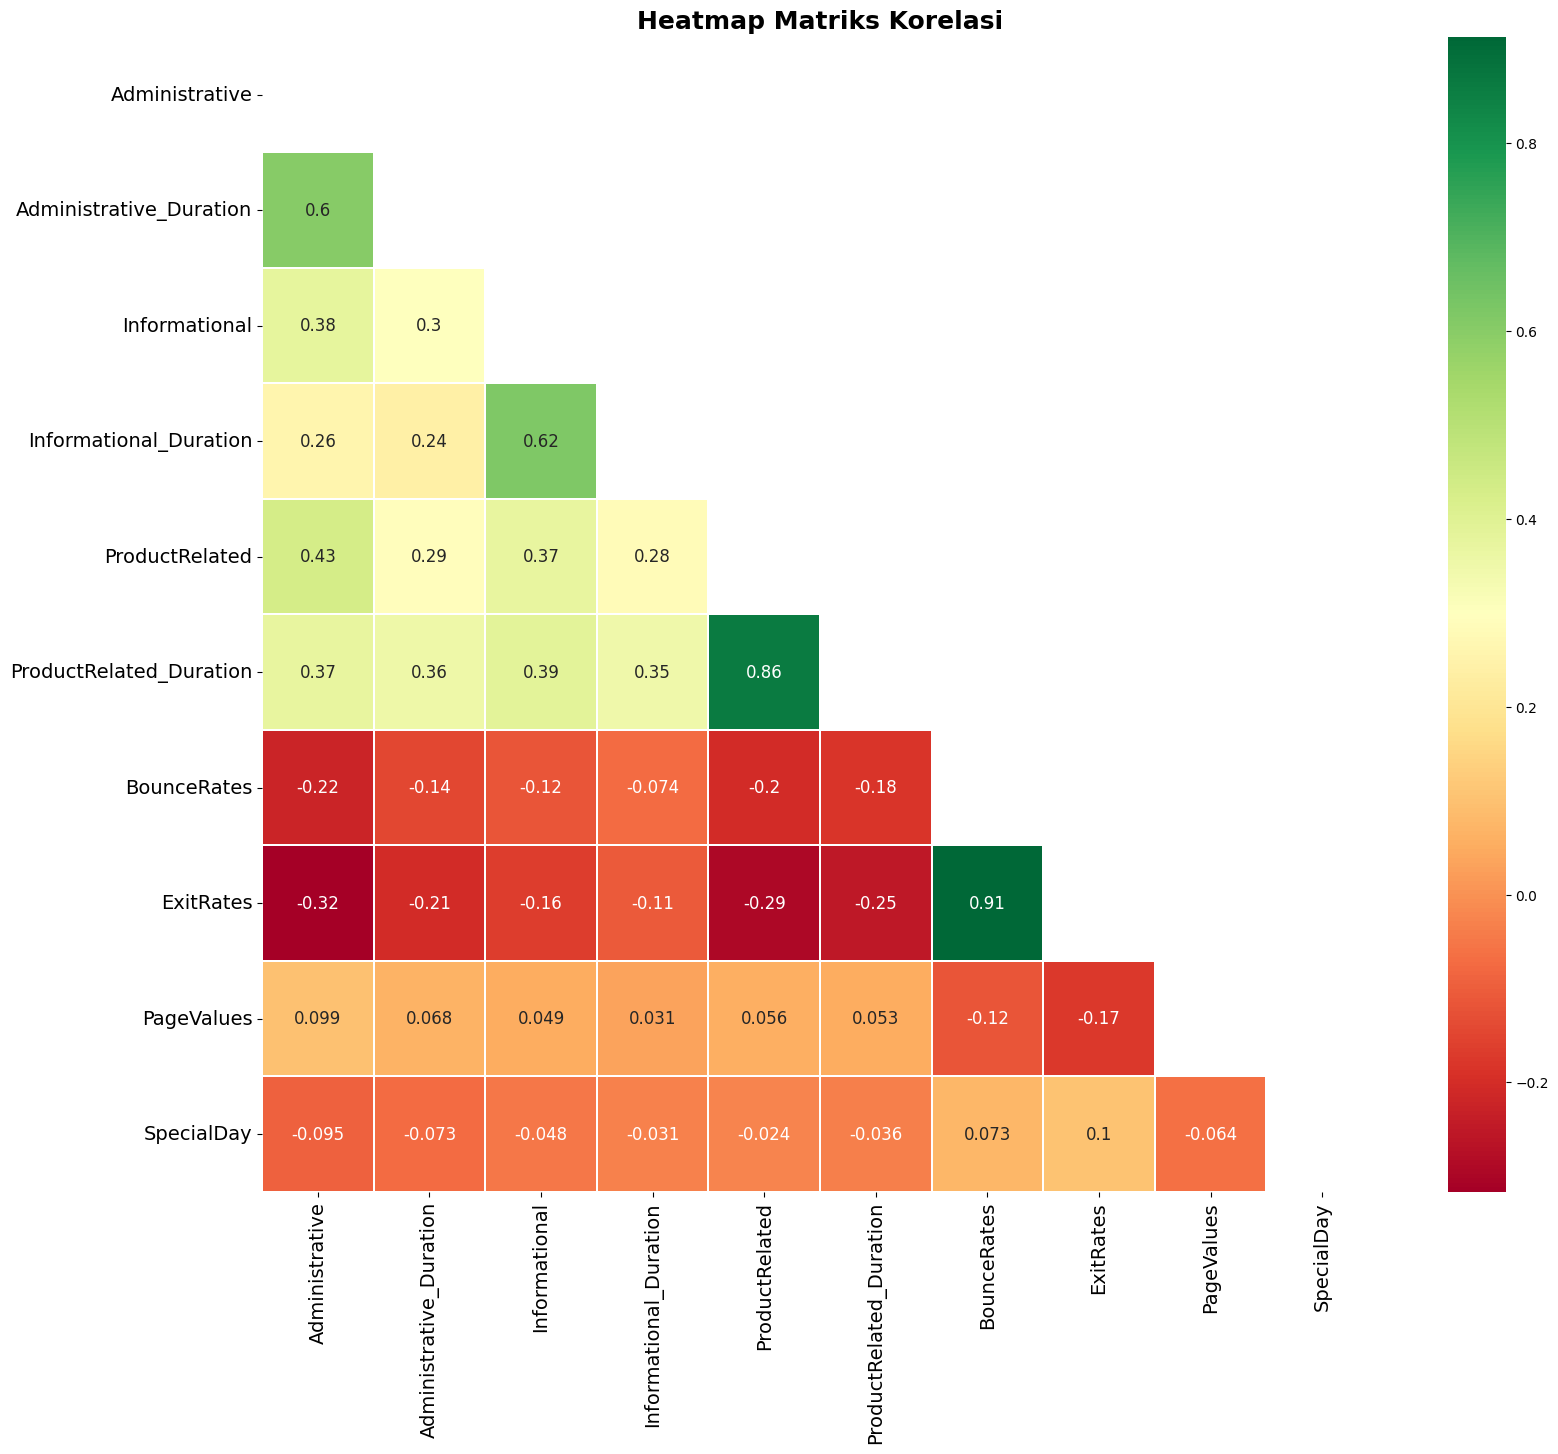

In [17]:
import numpy as np

numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

corr = df[numeric_cols].corr()

# Mask untuk menutupi segitiga atas
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.2,
    annot_kws={'size':12}
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Heatmap Matriks Korelasi', fontweight='bold', fontsize=18)

plt.show()

## **Hubungan Semua peubah Kategorik : Cramer V Heatmap**

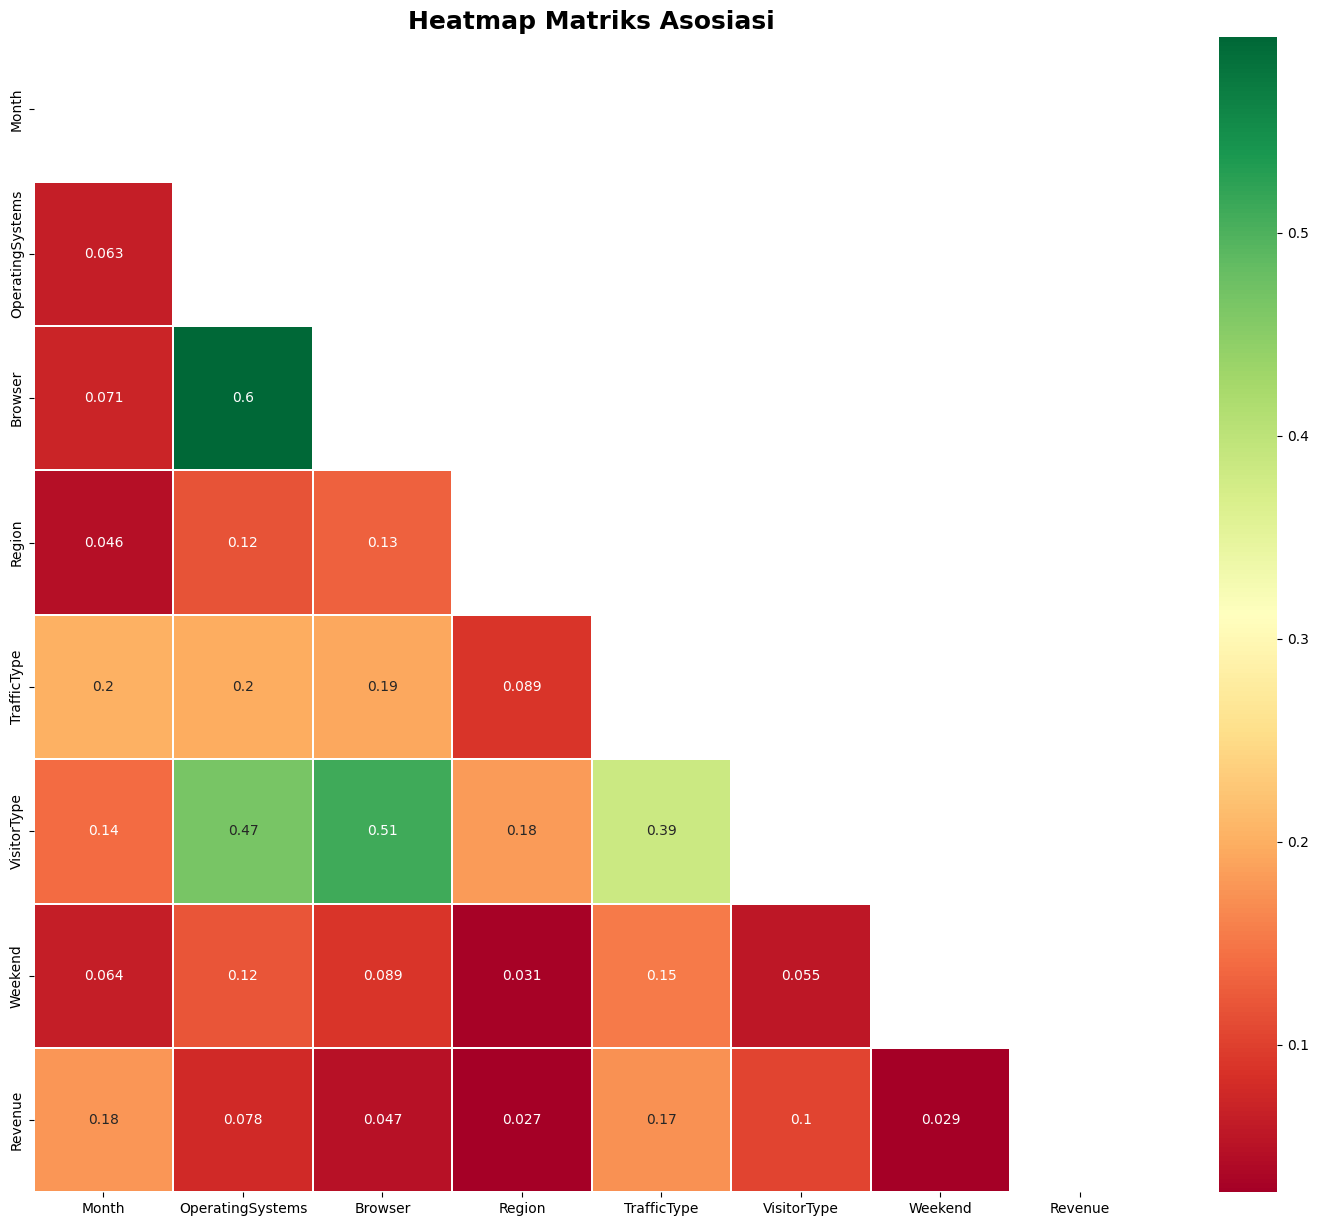

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

cat_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue"
]

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()

    r, k = contingency_table.shape

    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# buat matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# mask segitiga atas
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))

# plot
plt.figure(figsize=(18,15))

sns.heatmap(
    cramers_matrix,
    mask=mask,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.2
)

plt.title("Heatmap Matriks Asosiasi", fontweight='bold', fontsize=18)
plt.show()

# **TRANSAKSI**

## **Revenue Berdasarkan Bulan**

C:\Users\Dell\AppData\Local\Temp\ipykernel_4092\3847965208.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_data = df.groupby("Month")["Revenue"].sum().reset_index()


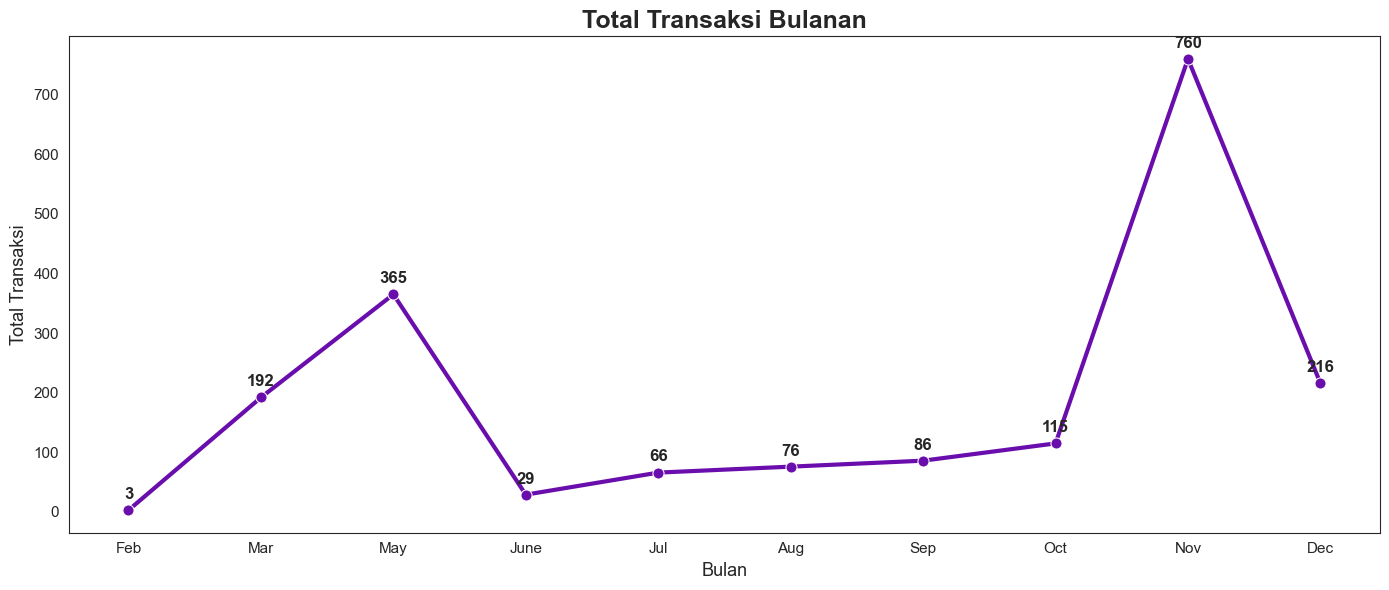

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

months = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_data = df.groupby("Month")["Revenue"].sum().reset_index()

monthly_data["Month"] = pd.Categorical(
    monthly_data["Month"],
    categories=months,
    ordered=True
)

monthly_data = monthly_data.sort_values("Month")

sns.set_style("white")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_data,
    x="Month",
    y="Revenue",
    marker="o",
    markersize=8,
    linewidth=3,
    color="#6A0DAD"
)

for x, y in zip(monthly_data["Month"], monthly_data["Revenue"]):
    plt.annotate(
        f"{y}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=12,
        weight="bold"
    )

plt.title("Total Transaksi Bulanan", fontsize=18, weight="bold")
plt.xlabel("Bulan", fontsize=13)
plt.ylabel("Total Transaksi", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(False)

plt.tight_layout()
plt.show()

## **Weekday vs Weekend Revenue**

C:\Users\Dell\AppData\Local\Temp\ipykernel_4092\256380435.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekend_conversion = df.groupby('Weekend')['Revenue'].mean().reset_index()


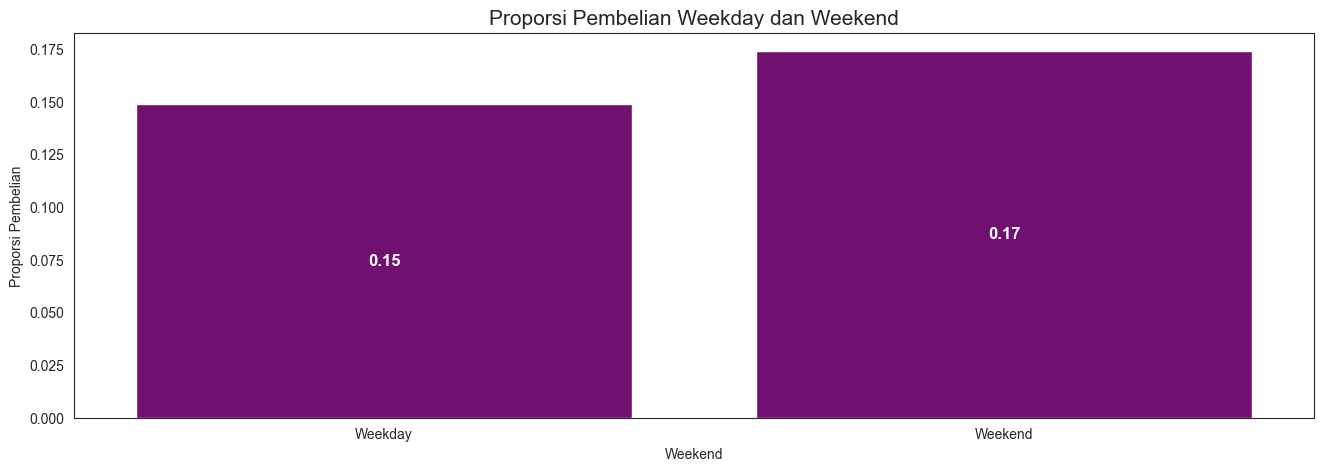

In [ ]:
plt.figure(figsize=(16,5))

weekend_conversion = df.groupby('Weekend')['Revenue'].mean().reset_index()

ax = sns.barplot(
    x="Weekend",
    y="Revenue",
    data=weekend_conversion,
    color="purple"
)

plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel("Proporsi Pembelian")
plt.title("Proporsi Pembelian Weekday dan Weekend", fontsize=15)

plt.grid(False)

for p in ax.patches:
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width()/2,
        height/2,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.show()

## **Waktu yang dihabiskan User**

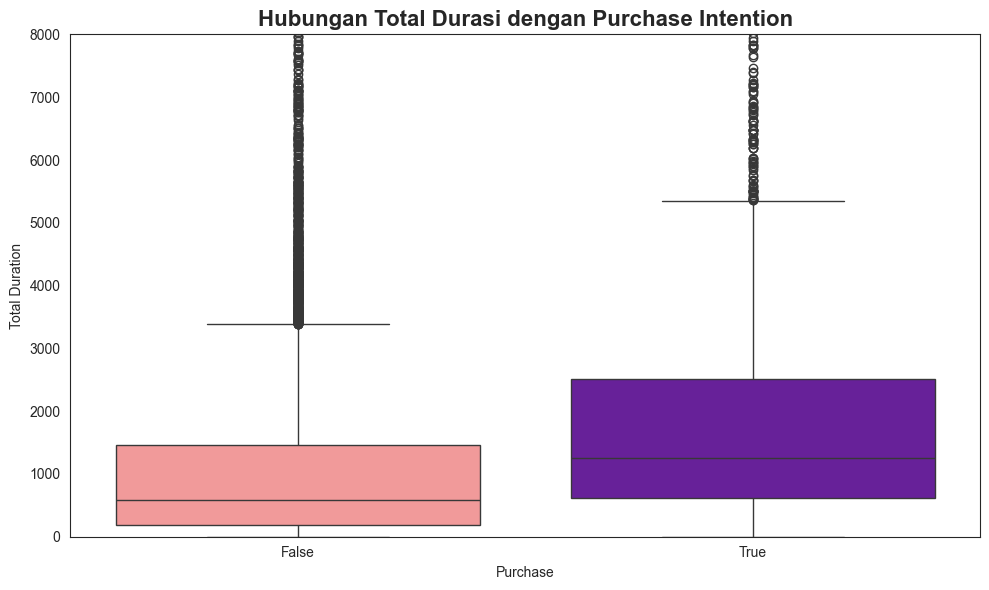

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# buat peubah baru total duration
df['total_Duration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

sns.set_style("white")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Revenue",
    y="total_Duration",
    hue="Revenue",
    palette=["#FF8C8C", "#6A0DAD"],
    legend=False
)

plt.title(
    "Hubungan Total Durasi dengan Purchase Intention",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Purchase")
plt.ylabel("Total Duration")

# atur batas sumbu Y
plt.ylim(0, 8000)

# hilangkan grid
plt.grid(False)

plt.tight_layout()
plt.show()

## **Jenis Customer**

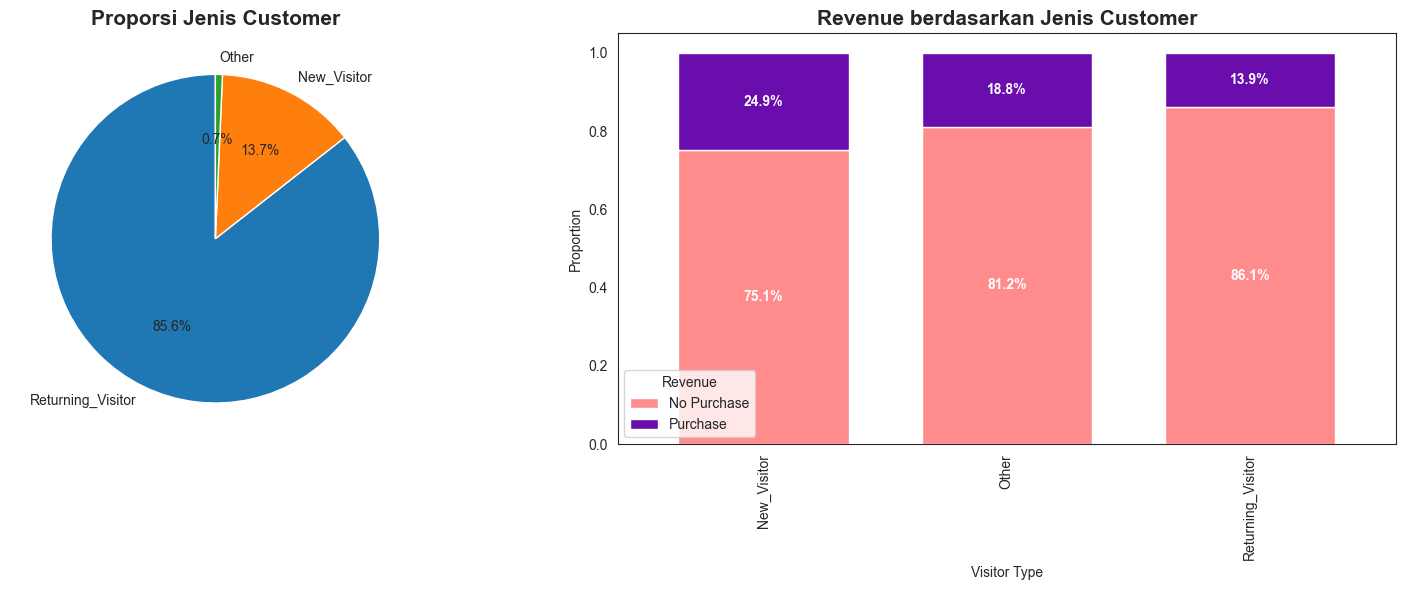

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

visitor_counts = df['VisitorType'].value_counts()
revenue_prop = pd.crosstab(
    df['VisitorType'],
    df['Revenue'],
    normalize='index'
)

revenue_count = pd.crosstab(
    df['VisitorType'],
    df['Revenue']
)
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].pie(
    visitor_counts,
    labels=visitor_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

ax[0].set_title(
    'Proporsi Jenis Customer',
    fontsize=15,
    fontweight='bold'
)
revenue_prop.plot(
    kind='bar',
    stacked=True,
    ax=ax[1],
    color=['#FF8C8C', '#6A0DAD'],
    width=0.7
)

# tampilkan proporsi di dalam bar
for i, visitor in enumerate(revenue_prop.index):

    cumulative = 0

    for j, rev in enumerate(revenue_prop.columns):

        proportion = revenue_prop.loc[visitor, rev]
        count = revenue_count.loc[visitor, rev]

        ax[1].text(
            i,
            cumulative + proportion/2,
            f'{proportion*100:.1f}%',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

        cumulative += proportion

# styling
ax[1].set_title(
    'Revenue berdasarkan Jenis Customer',
    fontsize=15,
    fontweight='bold'
)

ax[1].set_xlabel('Visitor Type')
ax[1].set_ylabel('Proportion')

ax[1].legend(
    title='Revenue',
    labels=['No Purchase', 'Purchase']
)

# hilangkan grid
ax[0].grid(False)
ax[1].grid(False)

plt.tight_layout()
plt.show()

## **Hubungan Peubah X Kategorik Terhadap Y**

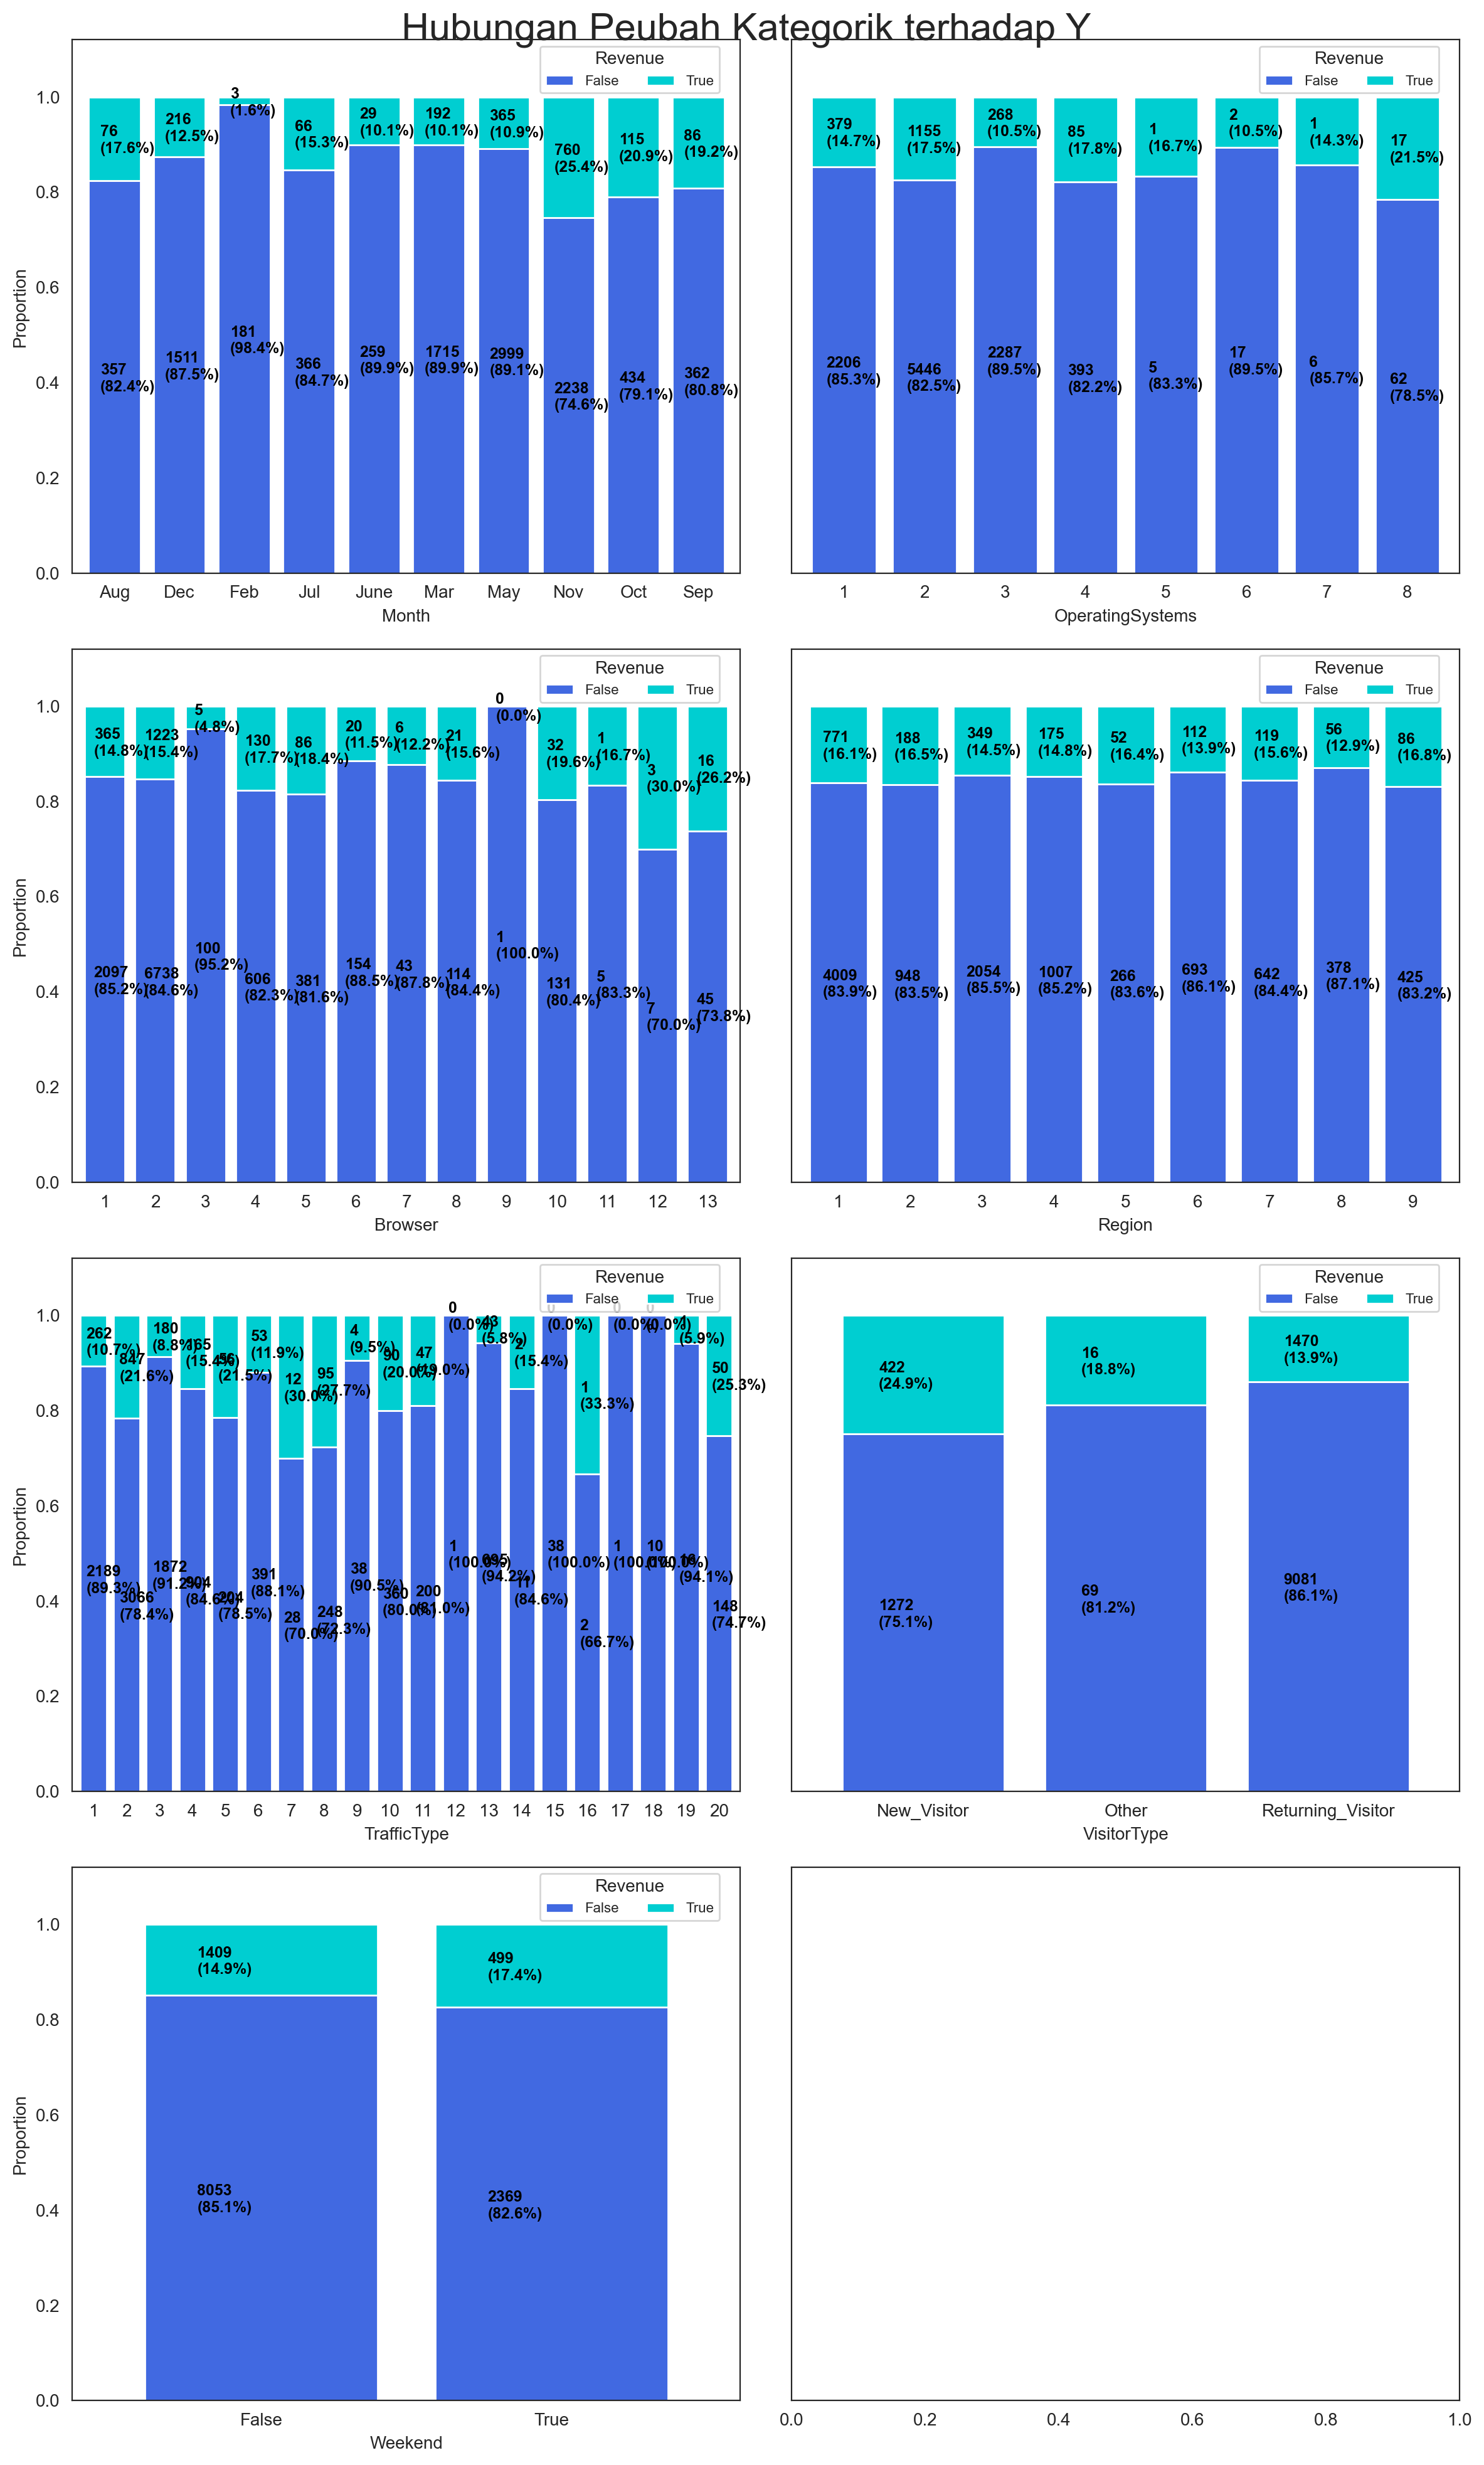

In [37]:
import math

Target = 'Revenue'

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, ax = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 5*n_rows),
    dpi=200
)

for i, col in enumerate(categorical_cols):

    cross_tab = pd.crosstab(
        index=df[col],
        columns=df[Target]
    )

    cross_tab_prop = pd.crosstab(
        index=df[col],
        columns=df[Target],
        normalize='index'
    )

    cmp = ListedColormap(['royalblue', 'darkturquoise'])

    x, y = i // n_cols, i % n_cols

    cross_tab_prop.plot(
        kind='bar',
        ax=ax[x, y],
        stacked=True,
        width=0.8,
        colormap=cmp,
        legend=False,
        ylabel='Proportion',
        sharey=True
    )

    # hilangkan grid
    ax[x, y].grid(False)

    for idx, val in enumerate(cross_tab.index.values):

        for (proportion, count, y_location) in zip(
            cross_tab_prop.loc[val],
            cross_tab.loc[val],
            cross_tab_prop.loc[val].cumsum()
        ):

            ax[x, y].text(
                x=idx-0.22,
                y=(y_location-proportion)+(proportion/2)-0.03,
                s=f'{count}\n({np.round(proportion*100,1)}%)',
                color="black",
                fontsize=9,
                fontweight="bold"
            )

    ax[x, y].legend(
        title='Revenue',
        loc=(0.7, 0.9),
        fontsize=8,
        ncol=2
    )

    ax[x, y].set_ylim([0, 1.12])

    ax[x, y].set_xticklabels(
        ax[x, y].get_xticklabels(),
        rotation=0
    )

plt.suptitle(
    'Hubungan Peubah Kategorik terhadap Y',
    fontsize=22
)

plt.tight_layout()
plt.show()

## **Hubungan Peubah X Numerik Terhadap Y**

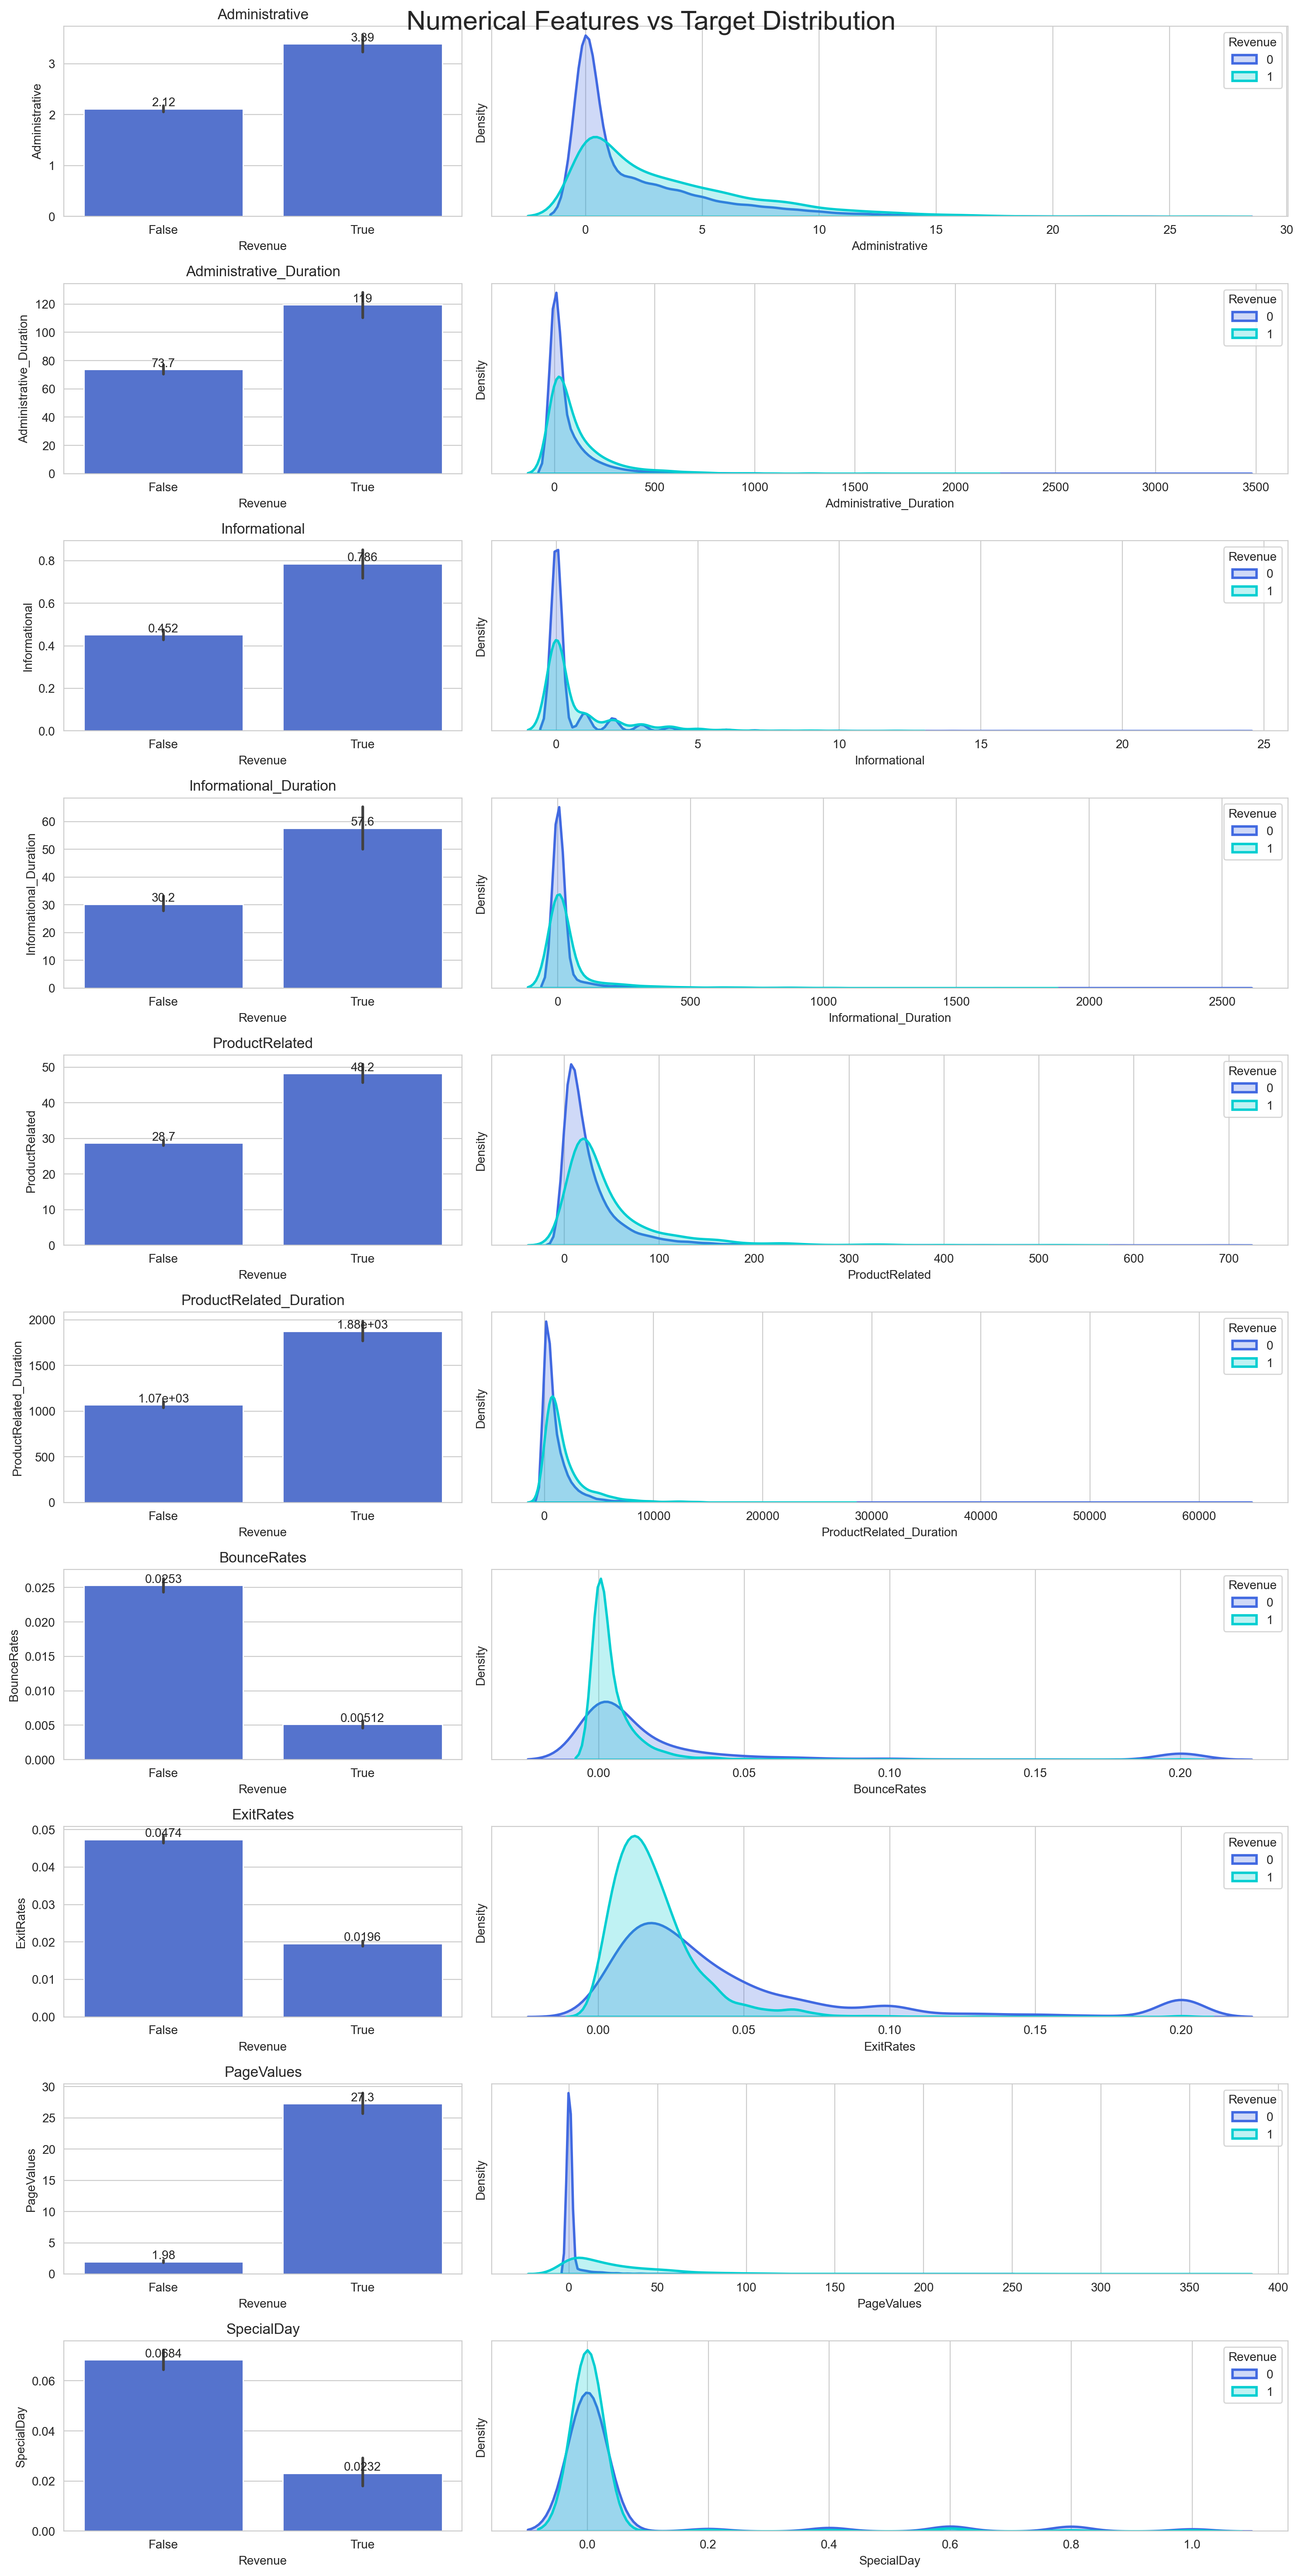

In [14]:
import math

sns.set_palette(['royalblue', 'darkturquoise'])

n_rows = len(numeric_cols)

fig, ax = plt.subplots(
    n_rows, 2,
    figsize=(15,3*n_rows),
    dpi=200,
    gridspec_kw={'width_ratios':[1,2]}
)

for i,col in enumerate(numeric_cols):

    graph = sns.barplot(
        data=df,
        x=Target,
        y=col,
        ax=ax[i,0]
    )

    sns.kdeplot(
        data=df[df[Target]==0],
        x=col,
        fill=True,
        linewidth=2,
        ax=ax[i,1],
        label='0'
    )

    sns.kdeplot(
        data=df[df[Target]==1],
        x=col,
        fill=True,
        linewidth=2,
        ax=ax[i,1],
        label='1'
    )

    ax[i,0].set_title(col)
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Revenue', loc='upper right')

    for cont in graph.containers:
        graph.bar_label(cont, fmt='%.3g')

plt.suptitle('Numerical Features vs Target Distribution', fontsize=22)
plt.tight_layout()
plt.show()

## **Peubah Y**

C:\Users\Dell\AppData\Local\Temp\ipykernel_4092\470123704.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Tidak Membeli', 'Membeli'], fontsize=12)
C:\Users\Dell\AppData\Local\Temp\ipykernel_4092\470123704.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Tidak Membeli', 'Membeli'], fontsize=12)


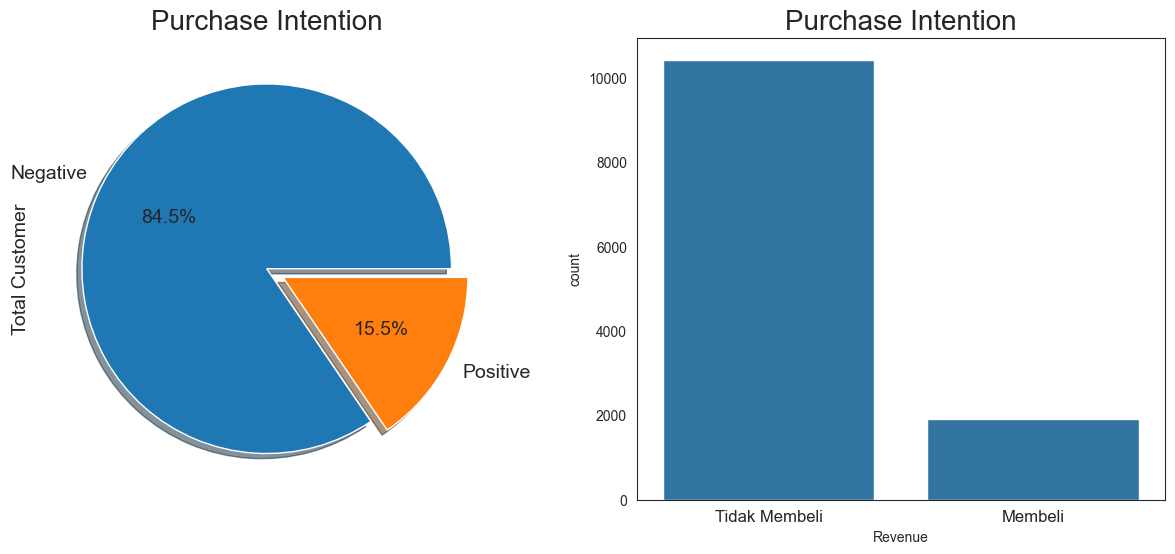

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(15, 6))

labels = ['Negative', 'Positive']

df['Revenue'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    labels=labels,
    fontsize=14
)

ax[0].set_title('Purchase Intention', fontsize=20)
ax[0].set_ylabel('Total Customer', fontsize=14)
sns.countplot(x='Revenue', data=df, ax=ax[1])

ax[1].set_title('Purchase Intention', fontsize=20)
ax[1].set_xticklabels(['Tidak Membeli', 'Membeli'], fontsize=12)

plt.show()

In [40]:
df['target'] = df['Revenue'].astype(int)
df['target'].value_counts()

target
0    10422
1     1908
Name: count, dtype: int64

## **Masalah Outlier**

In [43]:
outlier_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Administrative: 404 outliers
Administrative_Duration: 1172 outliers
Informational: 2631 outliers
Informational_Duration: 2405 outliers
ProductRelated: 987 outliers
ProductRelated_Duration: 961 outliers
BounceRates: 1551 outliers
ExitRates: 1099 outliers
PageValues: 2730 outliers
SpecialDay: 1251 outliers
